<a href="https://colab.research.google.com/github/whtan88/RandomDataAnalyst_Projects/blob/main/I_trained_8_traditional_ML_models_to_predict_stock_price_mvt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas-ta-classic
!pip install catboost

# Import libraries
import pandas_ta_classic as ta

import re
import numpy as np
import pandas as pd
import seaborn as sns
import yfinance as yf
from datetime import datetime,timedelta
from sklearn.preprocessing import StandardScaler # This should now work
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
import lightgbm as lgb
from catboost import CatBoostClassifier
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.calibration import CalibratedClassifierCV, calibration_curve, CalibrationDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report, roc_curve, roc_auc_score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 418.6/418.6 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.4 MB/s eta 0:00:00


In [ ]:
# Function
def feature_engineering_1(df,ticker):
  # Insert Feature engineering here
  return df

def feature_engineering_2(df, ticker):
  # Insert Feature engineering here
  return df

def prep_data(ticker, start_date, test_start_date, current_date):

  def flatten_multiindex_columns(df_to_flatten):
      new_columns = []
      for col in df_to_flatten.columns:
          if isinstance(col, tuple):
              clean_parts = [str(part) for part in col if str(part).strip()]
              if clean_parts:
                  new_columns.append('_'.join(clean_parts))
              else:
                  if len(col) > 0 and str(col[0]).strip():
                      new_columns.append(str(col[0]))
                  else:
                      new_columns.append('_'.join(map(str, col)))
          else:
              new_columns.append(str(col))
      df_to_flatten.columns = new_columns
      return df_to_flatten

  df = yf.download(ticker, start=start_date, end=current_date, interval='1d', auto_adjust=True).reset_index()
  df = df.sort_index()
  df = feature_engineering_1(df,ticker)
  df = feature_engineering_2(df,ticker)

  # Drop rows with NaN values after feature engineering but before splitting
  df.dropna(inplace=True)

  # Flatten columns after feature engineering
  df = flatten_multiindex_columns(df)

  # Corrected list_drop to match the actual DataFrame column names
  list_drop = ['target_close', ('Date',''), ('Close', ticker), ('High', ticker), ('Low', ticker), ('Open', ticker), ('Volume',ticker), 'cat_close', \
   ('SMA_5',''), ('SMA_10',''), ('SMA_20',''), ('EMA_5',''), ('EMA_10',''), ('EMA_20','')]

  # Reconstruct list_drop with flattened names
  list_drop_flattened = []
  for item in list_drop:
      if isinstance(item, tuple):
          clean_parts = [str(part) for part in item if str(part).strip()]
          if clean_parts:
              list_drop_flattened.append('_'.join(clean_parts))
          else:
              if len(item) > 0 and str(item[0]).strip():
                  list_drop_flattened.append(str(item[0]))
              else:
                  list_drop_flattened.append('_'.join(map(str, item)))
      else:
          list_drop_flattened.append(str(item))

  # Split dataframes based on the cleaned df
  # Use flattened column names
  df_train_raw = df[df['Date'] < test_start_date].copy()
  df_test_raw = df[df['Date'] >= test_start_date][:-1].copy() # Exclude the very last row for prediction
  df_predict_raw = df.iloc[-1:].copy()

  #print(df_test_raw['Date']) # Use flattened column name

  # Prepare target labels y_train and y_test from 'cat_close' before it's dropped from features
  y_train = df_train_raw['cat_close']
  y_test = df_test_raw['cat_close']

  # Extract the list of dates
  test_date = df_test_raw['Date']
  list_date = df_predict_raw['Date']

  # Drop non-feature columns from the dataframes BEFORE scaling
  # Use the flattened list_drop
  df_train = df_train_raw.drop(columns=list_drop_flattened)
  df_test = df_test_raw.drop(columns=list_drop_flattened)
  df_predict = df_predict_raw.drop(columns=list_drop_flattened)

  scaler = StandardScaler()

  # Apply scaler to the processed dataframes
  df_train_scaled = scaler.fit_transform(df_train)
  df_train = pd.DataFrame(df_train_scaled, columns=df_train.columns, index=df_train.index)

  df_test_scaled = scaler.transform(df_test) # Use transform, not fit_transform for test data
  df_test = pd.DataFrame(df_test_scaled, columns=df_test.columns, index=df_test.index)

  df_predict_scaled = scaler.transform(df_predict)
  df_predict = pd.DataFrame(df_predict_scaled, columns=df_predict.columns, index=df_predict.index)

  return df_train, y_train, df_test, y_test, df_predict, test_date, list_date

In [ ]:
# Feature Engineering and data processing pipeline

ticker = '^SPX'
start_date = '2020-01-01'
test_start_date = '2026-01-01'
current_date = '2026-06-30'

X_train, y_train, X_test, y_test, df_predict, test_date, list_date = prep_data(ticker, start_date, test_start_date, current_date)
X_train.head()

[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_979/3069328724.py:7: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  df = df.drop(columns=['day']) # Drop the original 'day' column
/tmp/ipykernel_979/3069328724.py:11: PerformanceWarning: indexing past lexsort depth may impact performance.
  df['month'] = df[('Date',)].dt.month
/tmp/ipykernel_979/3069328724.py:119: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'bb_{j}_period_{i}_std_low_to_upper'] = (df[('Low', ticker)] - df['bb_upper_band'])/df[f'SMA_{j}']
/tmp/ipykernel_979/3069328724.py:120: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many tim

,day_Monday,day_Thursday,day_Tuesday,day_Wednesday,month,sin_month,cos_month,ratio close to high T0,ratio close to low T0,ratio close to open T0,...,Bearish Marubozu T-2,Spinning_Tops_Doji T0,Spinning_Tops_Doji T-1,Spinning_Tops_Doji T-2,Bullish Hammer T0,Bearish Shooting Star T0,Bullish Harami T0,Bearish Harami T0,Bullish Engulfing T0,Bearish Engulfing T0
35,2.082536,-0.500424,-0.511009,-0.508895,-1.384651,1.257075,0.744003,-0.613439,-0.444469,-0.984256,...,0.218295,-0.334213,-0.334213,-0.537321,-0.341694,-0.349082,-0.108055,0.0,-0.058361,-0.149019
36,-0.480184,-0.500424,1.956913,-0.508895,-1.384651,1.257075,0.744003,-4.189321,-0.506946,-3.401658,...,0.218295,-0.334213,-0.334213,-0.537321,-0.341694,-0.349082,-0.108055,0.0,-0.058361,-0.149019
37,-0.480184,-0.500424,-0.511009,1.965041,-1.384651,1.257075,0.744003,-2.030147,-0.592966,-0.761817,...,0.218295,-0.334213,-0.334213,-0.537321,-0.341694,-0.349082,-0.108055,0.0,-0.058361,-0.149019
38,-0.480184,1.998304,-0.511009,-0.508895,-1.384651,1.257075,0.744003,-4.410500,-0.848368,-2.726292,...,0.218295,-0.334213,-0.334213,-0.537321,-0.341694,-0.349082,-0.108055,0.0,-0.058361,-0.149019
39,-0.480184,-0.500424,-0.511009,-0.508895,-1.384651,1.257075,0.744003,0.554198,3.672877,1.243497,...,0.218295,-0.334213,-0.334213,-0.537321,-0.341694,-0.349082,-0.108055,0.0,-0.058361,-0.149019


In [ ]:
# Training models
rs = 42

mdl_xgb = XGBClassifier(random_state=rs)
mdl_lr = LogisticRegression(random_state=rs, l1_ratio=0.5, max_iter=5000)
mdl_gnb = GaussianNB()
mdl_lgb = lgb.LGBMClassifier(random_state=rs)
mdl_cat = CatBoostClassifier(random_state=rs, verbose=0)
mdl_dt = DecisionTreeClassifier(random_state=rs)
mdl_rf = RandomForestClassifier(random_state=rs)
mdl_knn = KNeighborsClassifier()

model_name_list = ['XGBoost', 'Logistic Regression', 'Gaussian NB', 'LGBM', 'Catboost', 'Decision Tree', 'Random Forest', 'KNN']
model_list = [mdl_xgb, mdl_lr, mdl_gnb, mdl_lgb, mdl_cat, mdl_dt, mdl_rf, mdl_knn]

accuracy_list = []
precision_list = []
recall_list = []
roc_auc_list = []
pnl_list = []

for i in model_list:
  i.fit(X_train, y_train)
  y_pred = i.predict(X_test)
  predicted_proba = i.predict_proba(X_test)[:, 1]

  accuracy_list.append(accuracy_score(y_test, y_pred))
  precision_list.append(precision_score(y_test, y_pred))
  recall_list.append(recall_score(y_test, y_pred))
  roc_auc_list.append(round(roc_auc_score(y_test, predicted_proba),4))

  cumulative_PnL = [x == y for x, y in zip(y_pred, y_test)]
  cumulative_PnL = sum([50 if i == True else -400 for i in cumulative_PnL])
  pnl_list.append(cumulative_PnL)

df_mdl_performance = pd.DataFrame({'Model': model_name_list, 'Accuracy': accuracy_list, 'Precision': precision_list, 'Recall': recall_list, 'ROC AUC': roc_auc_list, 'PnL' : pnl_list})
df_mdl_performance.sort_values(by='Accuracy', ascending=False)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 800, number of negative: 673
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.018314 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 57477
[LightGBM] [Info] Number of data points in the train set: 1473, number of used features: 250
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.543109 -> initscore=0.172866
[LightGBM] [Info] Start training from score 0.172866


,Model,Accuracy,Precision,Recall,ROC AUC,PnL
6,Random Forest,0.533333,0.552941,0.723077,0.5601,-19200
4,Catboost,0.525000,0.543478,0.769231,0.4834,-19650
3,LGBM,0.516667,0.539326,0.738462,0.4982,-20100
0,XGBoost,0.491667,0.524390,0.661538,0.4775,-21450
5,Decision Tree,0.475000,0.513889,0.569231,0.4664,-22350
2,Gaussian NB,0.466667,0.507246,0.538462,0.4083,-22800
7,KNN,0.466667,0.507042,0.553846,0.4617,-22800
1,Logistic Regression,0.441667,0.484375,0.476923,0.4059,-24150


In [ ]:
from google.colab import drive

# This will prompt you to authorize access to your Google Drive
drive.mount('/content/drive')

import pickle
import os

drive_folder_path = '/content/drive/MyDrive/ml_models/XXX/'

# Create the folder if it doesn't exist yet
os.makedirs(drive_folder_path, exist_ok=True)

models_list = [
    ('Logistic Regression', mdl_lr),
    ('Gaussian NB', mdl_gnb),
    ('Decision Tree', mdl_dt),
    ('KNN', mdl_knn),
    ('LGBM', mdl_lgb),
    ('Catboost', mdl_cat),
    ('Random_Forest', mdl_rf),
    ('Xgboost', mdl_xgb),
    ('Soft_Voting_Classifier', soft_voting_clf),
    ('Hard_Voting_Classifier', hard_voting_clf)
]

# 3. Loop through the list and save each model
for model_name, model in models_list:
    file_path = os.path.join(drive_folder_path, f"XXX_{model_name}_start_2020_01_01_end_2026_01_01.pkl")

    with open(file_path, 'wb') as file:
        pickle.dump(model, file)

    print(f"Successfully saved {model_name} to '{file_path}'")

Mounted at /content/drive


NameError: name 'mdl_lr_0' is not defined

# Loading the models for assessment

In [ ]:
# Load Pickle Files
from google.colab import drive

# This will prompt you to authorize access to your Google Drive
drive.mount('/content/drive')

import pickle
import os

loaded_models = {}

drive_folder_path = '/content/drive/MyDrive/ml_models/0DTE_SPX_YT/'

for filename in os.listdir(drive_folder_path):
    if filename.endswith(".pkl"):
        # Extract model name by removing the '.pkl' extension
        model_name = os.path.splitext(filename)[0]
        file_path = os.path.join(drive_folder_path, filename)

        # Load the model
        with open(file_path, 'rb') as file:
            model = pickle.load(file)

        # Append as a tuple to your list
        class_name = type(model).__name__
        loaded_models[class_name] = model
print(loaded_models)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipykernel_2157/1141314184.py:22: UserWarning: [07:41:36] WARNING: /__w/xgboost/xgboost/src/collective/../data/../common/error_msg.h:83: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  model = pickle.load(file)


{'LogisticRegression': LogisticRegression(l1_ratio=0.5, max_iter=5000, penalty='elasticnet',
                   random_state=42, solver='saga'), 'GaussianNB': GaussianNB(), 'DecisionTreeClassifier': DecisionTreeClassifier(random_state=42), 'KNeighborsClassifier': KNeighborsClassifier(), 'LGBMClassifier': LGBMClassifier(random_state=42), 'CatBoostClassifier': CatBoostClassifier(random_state=42, verbose=0), 'RandomForestClassifier': RandomForestClassifier(random_state=42), 'XGBClassifier': XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_o

In [ ]:
# Summary stats of models

model_list = []
accuracy_list = []
precision_list = []
recall_list = []
roc_auc_list = []
pnl_list = []

for i in loaded_models:
  y_pred = loaded_models[i].predict(X_test)
  predicted_proba = loaded_models[i].predict_proba(X_test)[:, 1]

  model_list.append(i)
  accuracy_list.append(accuracy_score(y_test, y_pred))
  precision_list.append(precision_score(y_test, y_pred))
  recall_list.append(recall_score(y_test, y_pred))
  roc_auc_list.append(round(roc_auc_score(y_test, predicted_proba),4))
  cumulative_PnL = [x == y for x, y in zip(y_pred, y_test)]
  cumulative_PnL = sum([50 if i == True else -400 for i in cumulative_PnL])
  pnl_list.append(cumulative_PnL)

df_mdl_performance = pd.DataFrame({'Model': model_list, 'Accuracy': accuracy_list, 'Precision': precision_list, 'Recall': recall_list, 'ROC AUC': roc_auc_list, 'PnL' : pnl_list})
df_mdl_performance.sort_values(by='Accuracy', ascending=False)

,Model,Accuracy,Precision,Recall,ROC AUC,PnL
4,LGBMClassifier,0.541667,0.552083,0.815385,0.4839,-18750
8,VotingClassifier,0.541667,0.551020,0.830769,0.5046,-18750
5,CatBoostClassifier,0.541667,0.554348,0.784615,0.5049,-18750
6,RandomForestClassifier,0.533333,0.551724,0.738462,0.5709,-19200
7,XGBClassifier,0.525000,0.544444,0.753846,0.5592,-19650
3,KNeighborsClassifier,0.466667,0.507042,0.553846,0.4617,-22800
2,DecisionTreeClassifier,0.466667,0.506667,0.584615,0.4559,-22800
1,GaussianNB,0.458333,0.500000,0.446154,0.4083,-23250
0,LogisticRegression,0.441667,0.484375,0.476923,0.4112,-24150


# Calibrated Classifier / Platt Scaling

/usr/local/lib/python3.13/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


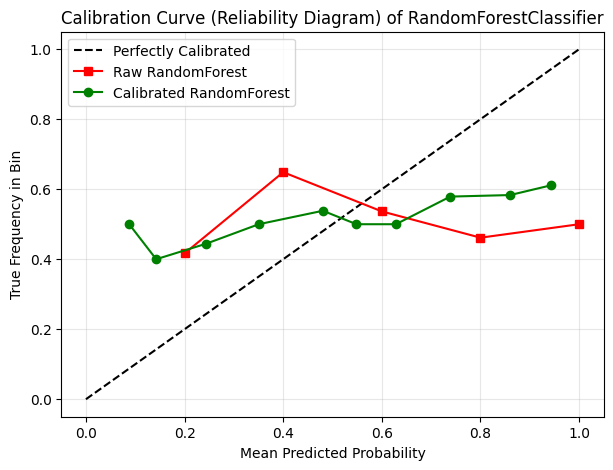

In [ ]:
# Train Calibrated model
calibrated_model = CalibratedClassifierCV(loaded_models['RandomForestClassifier'], method='sigmoid', cv='prefit')
calibrated_model.fit(X_train, y_train)

# Get positive class probabilities
cal_probs = calibrated_model.predict_proba(X_test)[:, 1]

# Generate curve coordinates
true_p_raw, pred_p_raw = calibration_curve(y_test, predicted_proba, n_bins=10)
true_p_cal, pred_p_cal = calibration_curve(y_test, cal_probs, n_bins=10)

# Plot Results
plt.figure(figsize=(7, 5))
plt.plot([0, 1], [0, 1], "k--", label="Perfectly Calibrated")
plt.plot(pred_p_raw, true_p_raw, "s-", color="red", label="Raw RandomForest")
plt.plot(pred_p_cal, true_p_cal, "o-", color="green", label="Calibrated RandomForest")

plt.ylabel("True Frequency in Bin")
plt.xlabel("Mean Predicted Probability")
plt.title("Calibration Curve (Reliability Diagram) of RandomForestClassifier")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

/usr/local/lib/python3.13/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


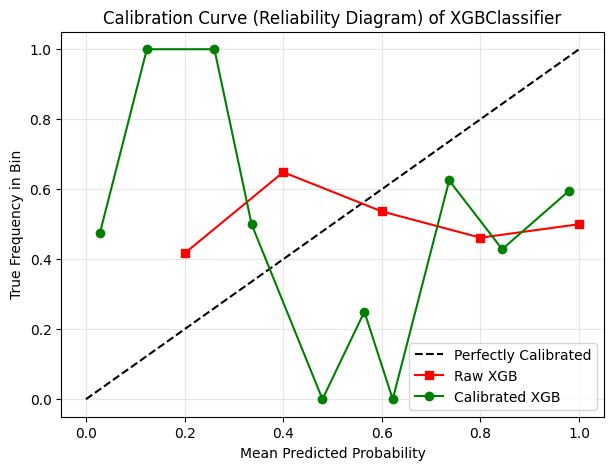

In [ ]:
# Train Calibrated model
calibrated_model = CalibratedClassifierCV(loaded_models['XGBClassifier'], method='sigmoid', cv='prefit')
calibrated_model.fit(X_train, y_train)

# Get positive class probabilities
cal_probs = calibrated_model.predict_proba(X_test)[:, 1]

# Generate curve coordinates
true_p_raw, pred_p_raw = calibration_curve(y_test, predicted_proba, n_bins=10)
true_p_cal, pred_p_cal = calibration_curve(y_test, cal_probs, n_bins=10)

# Plot Results
plt.figure(figsize=(7, 5))
plt.plot([0, 1], [0, 1], "k--", label="Perfectly Calibrated")
plt.plot(pred_p_raw, true_p_raw, "s-", color="red", label="Raw XGB")
plt.plot(pred_p_cal, true_p_cal, "o-", color="green", label="Calibrated XGB")

plt.ylabel("True Frequency in Bin")
plt.xlabel("Mean Predicted Probability")
plt.title("Calibration Curve (Reliability Diagram) of XGBClassifier")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

/usr/local/lib/python3.13/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


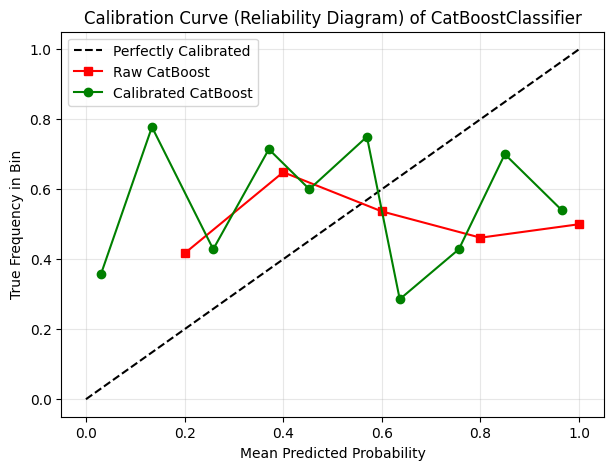

In [ ]:
# Train Calibrated model
calibrated_model = CalibratedClassifierCV(loaded_models['CatBoostClassifier'], method='sigmoid', cv='prefit')
calibrated_model.fit(X_train, y_train)

# Get positive class probabilities
cal_probs = calibrated_model.predict_proba(X_test)[:, 1]

# Generate curve coordinates
true_p_raw, pred_p_raw = calibration_curve(y_test, predicted_proba, n_bins=10)
true_p_cal, pred_p_cal = calibration_curve(y_test, cal_probs, n_bins=10)

# Plot Results
plt.figure(figsize=(7, 5))
plt.plot([0, 1], [0, 1], "k--", label="Perfectly Calibrated")
plt.plot(pred_p_raw, true_p_raw, "s-", color="red", label="Raw CatBoost")
plt.plot(pred_p_cal, true_p_cal, "o-", color="green", label="Calibrated CatBoost")

plt.ylabel("True Frequency in Bin")
plt.xlabel("Mean Predicted Probability")
plt.title("Calibration Curve (Reliability Diagram) of CatBoostClassifier")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Live Testing Results for 2 Months (Aug - Sep 2026)

In [ ]:
import gspread
from google.colab import auth
from google.auth import default

# 1. Authenticate and authorize gspread
auth.authenticate_user()
creds, _ = default()
gc = gspread.authorize(creds)

# 2. Open spreadsheet by URL and select worksheet
sheet_url = 'https://docs.google.com/spreadsheets/XXXXXXX/edit'
spreadsheet = gc.open_by_url(sheet_url)
worksheet = spreadsheet.worksheet("0DTE_SPX")

# 3. Extract all records into a list of dicts and convert to DataFrame
data = worksheet.get_all_records()
df_live_data = pd.DataFrame(data)

# Display data for Aug and Sept
df_live_data = df_live_data[df_live_data['TradeDate']< '2026-10-01']

# Remove 1 day with no records
df_live_data = df_live_data[df_live_data['TradeDate'] != '2026-08-28'].copy()

# Convert columns accordingly
df_live_data['TradeDate'] = pd.to_datetime(df_live_data['TradeDate'])
df_live_data['Actual Direction'] = pd.to_numeric(df_live_data['Actual Direction'], errors='coerce').fillna(0).astype(int)
df_live_data['RF predicted'] = pd.to_numeric(df_live_data['RF predicted'], errors='coerce').fillna(0).astype(int)
df_live_data['XGB predicted'] = pd.to_numeric(df_live_data['XGB predicted'], errors='coerce').fillna(0).astype(int)
df_live_data['Catboost predicted'] = pd.to_numeric(df_live_data['Catboost predicted'], errors='coerce').fillna(0).astype(int)


df_live_data.head()

,TradeDate,RF predicted,XGB predicted,Catboost predicted,RF predicted proba,XGB predicted proba,Catboost predicted proba,Actual Direction,PreTradeDay Analysis,TradeDay analysis on hourly & 5min,PostTradeDay Analysis
0,2026-08-03,1,1,1,0.51,0.538,0.54,1,Seems to be bullish based on daily candlestick...,Jumped within the first hour,Mistakenly bought 1DTE option as well.
1,2026-08-04,1,1,1,0.62,0.948,0.686,1,Seems to hit the upper bound of bollinger band...,Bought 1 position and index price moved too fa...,Was greedy and mistakenly bought against the t...
2,2026-08-05,1,1,1,0.55,0.542,0.583,0,Past few days have been consecutive huge green...,"Slowly entered positions within the 1st hour, ...",It moved in the correct direction as expected.
3,2026-08-06,1,1,1,0.55,0.601,0.571,0,Prev day was a slight drop from past few days ...,"Slowly entered positions within the 1st hour, ...",Index price ended slightly lower. Might be bul...
4,2026-08-07,1,1,1,0.51,0.503,0.622,1,Gravestone doji formed on the previous day. Po...,Only managed to enter 1 position at the start ...,It moved in the correct direction as predicted...


In [ ]:
# Print results
print(f'No. of days of trading data: {len(df_live_data)}')
print(f'Random Forest Accuracy : {round(accuracy_score(df_live_data["Actual Direction"], df_live_data["RF predicted"]),4)}')
print(f'XGBoost Accuracy : {round(accuracy_score(df_live_data["Actual Direction"], df_live_data["XGB predicted"]),4)}')
print(f'Catboost Accuracy : {round(accuracy_score(df_live_data["Actual Direction"], df_live_data["Catboost predicted"]),4)}')

No. of days of trading data: 41
Random Forest Accuracy : 0.5366
XGBoost Accuracy : 0.5122
Catboost Accuracy : 0.5122


In [ ]:
def bin_probabilities(df, prob_columns, bins=[0.0, 0.4, 0.5, 0.6, 0.8, 1.0], labels=['Very Low (0-0.4)', 'Low (0.4-0.5)', 'Medium (0.5-0.6)', 'High (0.6-0.8)', 'Very High (0.8-1.0)']):
    """
    Bins the specified probability columns in a DataFrame into categorized buckets.
    """
    for col in prob_columns:
        # Ensure the column is treated as numeric
        numeric_probs = pd.to_numeric(df[col], errors='coerce').fillna(0.5)
        new_col_name = col.replace('proba', 'bucket')
        df[new_col_name] = pd.cut(numeric_probs, bins=bins, labels=labels, include_lowest=True)
    return df

# Define the columns that contain predicted probabilities
proba_cols = ['RF predicted proba', 'XGB predicted proba', 'Catboost predicted proba']

# Apply the binning function
df_live_data = bin_probabilities(df_live_data, proba_cols)

# Check if prediction is correct
df_live_data['RF Prediction Correct'] = np.where(df_live_data['Actual Direction'] == df_live_data['RF predicted'], 1, 0)
df_live_data['XGB Prediction Correct'] = np.where(df_live_data['Actual Direction'] == df_live_data['XGB predicted'], 1, 0)
df_live_data['Catboost Prediction Correct'] = np.where(df_live_data['Actual Direction'] == df_live_data['Catboost predicted'], 1, 0)

,TradeDate,RF predicted,XGB predicted,Catboost predicted,RF predicted proba,XGB predicted proba,Catboost predicted proba,Actual Direction,PreTradeDay Analysis,TradeDay analysis on hourly & 5min,PostTradeDay Analysis,RF predicted bucket,XGB predicted bucket,Catboost predicted bucket,RF Prediction Correct,XGB Prediction Correct,Catboost Prediction Correct
0,2026-08-03,1,1,1,0.51,0.538,0.54,1,Seems to be bullish based on daily candlestick...,Jumped within the first hour,Mistakenly bought 1DTE option as well.,Medium (0.5-0.6),Medium (0.5-0.6),Medium (0.5-0.6),1,1,1
1,2026-08-04,1,1,1,0.62,0.948,0.686,1,Seems to hit the upper bound of bollinger band...,Bought 1 position and index price moved too fa...,Was greedy and mistakenly bought against the t...,High (0.6-0.8),Very High (0.8-1.0),High (0.6-0.8),1,1,1
2,2026-08-05,1,1,1,0.55,0.542,0.583,0,Past few days have been consecutive huge green...,"Slowly entered positions within the 1st hour, ...",It moved in the correct direction as expected.,Medium (0.5-0.6),Medium (0.5-0.6),Medium (0.5-0.6),0,0,0
3,2026-08-06,1,1,1,0.55,0.601,0.571,0,Prev day was a slight drop from past few days ...,"Slowly entered positions within the 1st hour, ...",Index price ended slightly lower. Might be bul...,Medium (0.5-0.6),High (0.6-0.8),Medium (0.5-0.6),0,0,0
4,2026-08-07,1,1,1,0.51,0.503,0.622,1,Gravestone doji formed on the previous day. Po...,Only managed to enter 1 position at the start ...,It moved in the correct direction as predicted...,Medium (0.5-0.6),Medium (0.5-0.6),High (0.6-0.8),1,1,1


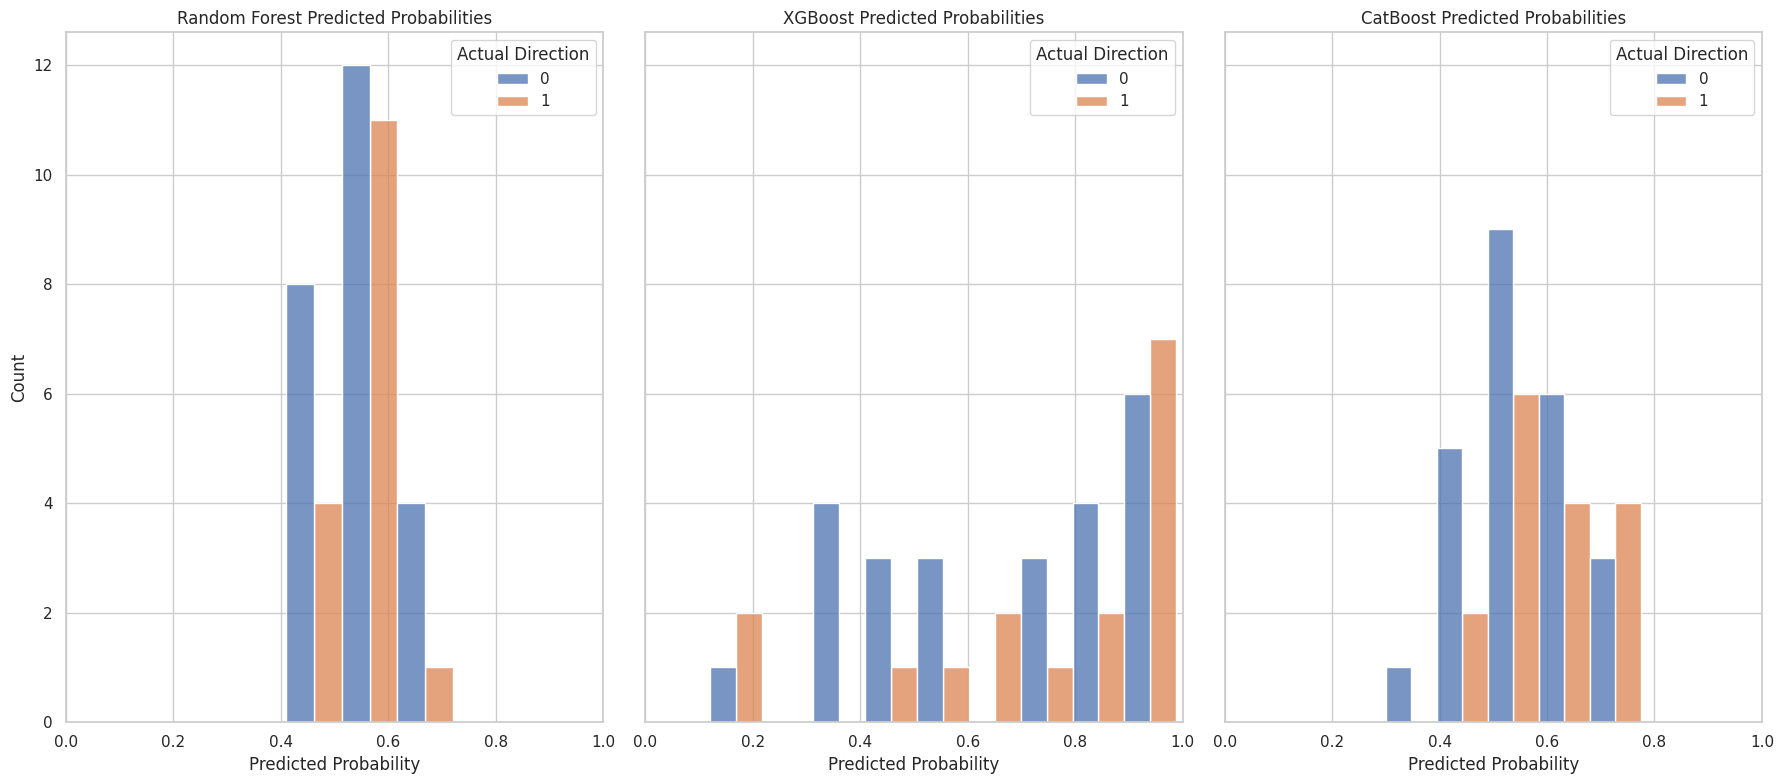

In [ ]:
# Histogram plots of the probability distributions
# Ensure the probability columns are numeric before plotting
plot_df = df_live_data.copy()
for col in ['RF predicted proba', 'XGB predicted proba', 'Catboost predicted proba']:
    plot_df[col] = pd.to_numeric(plot_df[col], errors='coerce')

# Set up the plotting grid
fig, axes = plt.subplots(1, 3, figsize=(18, 8), sharey=True)

model_probas = [
    ('RF predicted proba', 'Random Forest'),
    ('XGB predicted proba', 'XGBoost'),
    ('Catboost predicted proba', 'CatBoost')
]

for idx, (col_name, model_name) in enumerate(model_probas):
    sns.histplot(
        data=plot_df,
        x=col_name,
        binwidth=0.1,
        hue='Actual Direction',
        multiple='dodge',
        kde=False,
        ax=axes[idx],
    )
    axes[idx].set_title(f'{model_name} Predicted Probabilities')
    axes[idx].set_xlabel('Predicted Probability')
    axes[idx].set_ylabel('Count')
    axes[idx].set_xlim(0, 1)

plt.tight_layout()
plt.show()

In [ ]:
# Check Random Forest Prediction Results 1
df_live_data[['RF predicted bucket', 'TradeDate', 'RF Prediction Correct']].pivot_table(index='RF predicted bucket', columns='RF Prediction Correct', values='TradeDate', aggfunc='count').reset_index()

/tmp/ipykernel_979/2959287542.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df_live_data[['RF predicted bucket', 'TradeDate', 'RF Prediction Correct']].pivot_table(index='RF predicted bucket', columns='RF Prediction Correct', values='TradeDate', aggfunc='count').reset_index()


RF Prediction Correct,RF predicted bucket,0,1
0,Very Low (0-0.4),0,0
1,Low (0.4-0.5),2,8
2,Medium (0.5-0.6),13,13
3,High (0.6-0.8),4,1
4,Very High (0.8-1.0),0,0


In [ ]:
# Check Random Forest Prediction Results 2
df_live_data[['RF predicted bucket', 'RF Prediction Correct']].groupby('RF predicted bucket').mean().reset_index()

/tmp/ipykernel_979/1882043543.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_live_data[['RF predicted bucket', 'RF Prediction Correct']].groupby('RF predicted bucket').mean().reset_index()


,RF predicted bucket,RF Prediction Correct
0,Very Low (0-0.4),NaN
1,Low (0.4-0.5),0.8
2,Medium (0.5-0.6),0.5
3,High (0.6-0.8),0.2
4,Very High (0.8-1.0),NaN


In [ ]:
# Check XGB Prediction Results 1
df_live_data[['XGB predicted bucket', 'TradeDate', 'XGB Prediction Correct']].pivot_table(index='XGB predicted bucket', columns='XGB Prediction Correct', values='TradeDate', aggfunc='count').reset_index()

/tmp/ipykernel_979/4194644199.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df_live_data[['XGB predicted bucket', 'TradeDate', 'XGB Prediction Correct']].pivot_table(index='XGB predicted bucket', columns='XGB Prediction Correct', values='TradeDate', aggfunc='count').reset_index()


XGB Prediction Correct,XGB predicted bucket,0,1
0,Very Low (0-0.4),2,4
1,Low (0.4-0.5),0,3
2,Medium (0.5-0.6),4,2
3,High (0.6-0.8),4,3
4,Very High (0.8-1.0),10,9


In [ ]:
# Check XGB Prediction Results 2
df_live_data[['XGB predicted bucket', 'XGB Prediction Correct']].groupby('XGB predicted bucket').mean().reset_index()

/tmp/ipykernel_979/2814707490.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_live_data[['XGB predicted bucket', 'XGB Prediction Correct']].groupby('XGB predicted bucket').mean().reset_index()


,XGB predicted bucket,XGB Prediction Correct
0,Very Low (0-0.4),0.666667
1,Low (0.4-0.5),1.000000
2,Medium (0.5-0.6),0.333333
3,High (0.6-0.8),0.428571
4,Very High (0.8-1.0),0.473684


In [ ]:
# Check Catboost Prediction Results 1
df_live_data[['Catboost predicted bucket', 'TradeDate', 'Catboost Prediction Correct']].pivot_table(index='Catboost predicted bucket', columns='Catboost Prediction Correct', values='TradeDate', aggfunc='count').reset_index()

/tmp/ipykernel_979/2631184027.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df_live_data[['Catboost predicted bucket', 'TradeDate', 'Catboost Prediction Correct']].pivot_table(index='Catboost predicted bucket', columns='Catboost Prediction Correct', values='TradeDate', aggfunc='count').reset_index()


Catboost Prediction Correct,Catboost predicted bucket,0,1
0,Very Low (0-0.4),0,1
1,Low (0.4-0.5),2,6
2,Medium (0.5-0.6),11,7
3,High (0.6-0.8),7,7
4,Very High (0.8-1.0),0,0


In [ ]:
# Check Catboost Prediction Results 2
df_live_data[['Catboost predicted bucket', 'Catboost Prediction Correct']].groupby('Catboost predicted bucket').mean().reset_index()

/tmp/ipykernel_979/511051593.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_live_data[['Catboost predicted bucket', 'Catboost Prediction Correct']].groupby('Catboost predicted bucket').mean().reset_index()


,Catboost predicted bucket,Catboost Prediction Correct
0,Very Low (0-0.4),1.000000
1,Low (0.4-0.5),0.750000
2,Medium (0.5-0.6),0.388889
3,High (0.6-0.8),0.500000
4,Very High (0.8-1.0),NaN
